In [1]:
import torch
from torch import nn, optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt

In [2]:
device = torch.device('mps' if torch.mps.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: mps


In [50]:
# Define transformations
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # Normalize to mean 0, std 1
])

# Load datasets
training_set = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_set = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

# Create data loaders
batch_size = 32
train_dataloader = DataLoader(training_set, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(test_set, batch_size=batch_size, shuffle=False)

In [23]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=(3,3), padding='same')  
        self.pool = nn.MaxPool2d(2, 2)                                    
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=(3,3), padding='same') 
        self.fc1 = nn.Linear(64 * 7 * 7, 128) 
        self.fc2 = nn.Linear(128, 10)
        self.flatten = nn.Flatten()                                     
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.25)
        
    def forward(self, x):
                                            # Input:  1  x 28 x 28
        x = self.relu(self.conv1(x))        # Output: 32 x 28 x 28
        x = self.pool(x)                    # Output: 32 x 14 x 14
        x = self.relu(self.conv2(x))        # Output: 64 x 14 x 14
        x = self.pool(x)                    # Output: 64 x 7 x 7
        x = self.flatten(x)                 # Output: 64 * 7 * 7 = 3136
        x = self.relu(self.fc1(x))          # Fully connected layer
        x = self.dropout(x)
        x = self.fc2(x)                     # notera att vi faktiskt EJ behöver explicit ange softmax aktivering här på output layer
                                            # anledningen är att vi i nästa skede använder CrossEntropyLoss, och den har faktiskt
                                            # softmax-aktivering inbakad i sig. Med andra ord sköter CrossEntropyLoss den sista aktiveringen åt oss.
                                                                                  
        return x

In [24]:
model = CNN()
model = model.to(device)  # Move to device
print(model)

CNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (relu): ReLU()
  (dropout): Dropout(p=0.25, inplace=False)
)


In [7]:
EPOCHS = 20
LEARNING_RATE = 0.005


model = CNN()
model = model.to(device)

optimizer = optim.SGD(model.parameters(), lr=LEARNING_RATE)
loss_function = nn.CrossEntropyLoss()

# ----------------------------------------------------------------------------

batch_train_losses = []
epoch_train_losses = []
epoch_test_losses = []
epoch_test_accuracies = []

for epoch in range(EPOCHS):
    print(f"Epoch {epoch+1}/{EPOCHS}")
    
    model.train()  # Set model to training mode

    
    for batch in train_dataloader:
        input_features, y_true = batch
        input_features, y_true = input_features.to(device), y_true.to(device)
        
        y_pred = model(input_features)  
        loss = loss_function(y_pred, y_true)  
        loss.backward()  
        optimizer.step()  
        optimizer.zero_grad()  
        
        batch_loss = loss.item()
        batch_train_losses.append(batch_loss)
    
    
    epoch_average_loss = np.average(batch_train_losses[-len(train_dataloader):])
    epoch_train_losses.append(epoch_average_loss)
    print(f"Training loss: {epoch_average_loss}")
    
    # ----------------------------------------
    # Evaluation section
    # ----------------------------------------
    
    model.eval()  # Set model to evaluation mode

    with torch.no_grad(): 
      
        x_test, y_test = next(iter(test_dataloader))
        x_test, y_test = x_test.to(device), y_test.to(device)
        
        y_pred = model(x_test)
        test_loss = loss_function(y_pred, y_test).item()
        epoch_test_losses.append(test_loss)
        print(f"Test loss: {test_loss}")
        
        # Evaluation accuracy
        _, predicted_class = torch.max(y_pred, dim=1)
        accuracy = (predicted_class == y_test).float().mean().item()
        epoch_test_accuracies.append(accuracy)
        print(f"Test accuracy: {accuracy}")

Epoch 1/20
Training loss: 0.9654163504362107
Test loss: 0.7424506545066833
Test accuracy: 0.71875
Epoch 2/20
Training loss: 0.538267784412702
Test loss: 0.6526604890823364
Test accuracy: 0.78125
Epoch 3/20
Training loss: 0.4694789275248845
Test loss: 0.5616568326950073
Test accuracy: 0.84375
Epoch 4/20
Training loss: 0.4249824496746063
Test loss: 0.49599123001098633
Test accuracy: 0.84375
Epoch 5/20
Training loss: 0.39761966754198075
Test loss: 0.43635791540145874
Test accuracy: 0.84375
Epoch 6/20
Training loss: 0.3760263964215914
Test loss: 0.43860453367233276
Test accuracy: 0.90625
Epoch 7/20
Training loss: 0.3596812332034111
Test loss: 0.4551393985748291
Test accuracy: 0.875
Epoch 8/20
Training loss: 0.3450880150516828
Test loss: 0.3880366086959839
Test accuracy: 0.90625
Epoch 9/20
Training loss: 0.331948223610719
Test loss: 0.41632434725761414
Test accuracy: 0.90625
Epoch 10/20
Training loss: 0.32142304057478904
Test loss: 0.42740511894226074
Test accuracy: 0.90625
Epoch 11/20
Trai

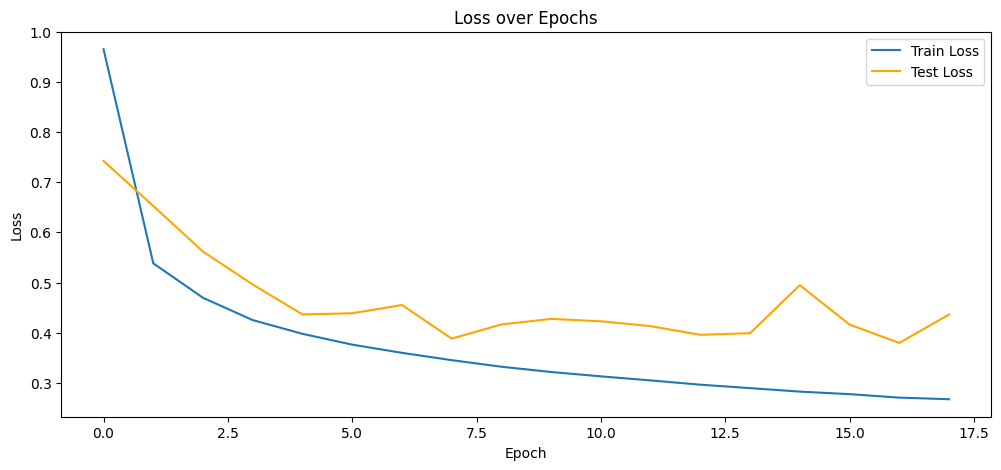

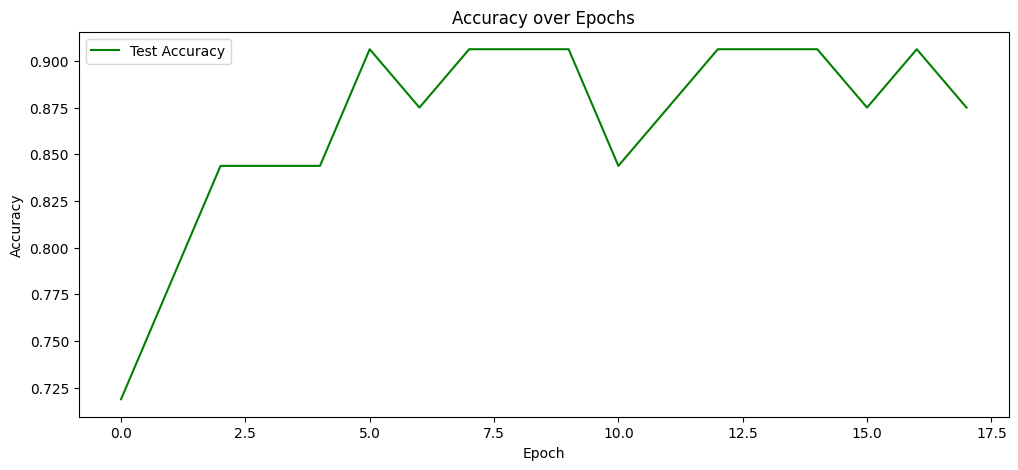

In [8]:
# Plot loss curves
plt.figure(figsize=(12, 5))
plt.plot(epoch_train_losses[:-2], label='Train Loss')
plt.plot(epoch_test_losses[:-2], label='Test Loss', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss over Epochs')
plt.show()

# Plot test accuracies
plt.figure(figsize=(12, 5))
plt.plot(epoch_test_accuracies[:-2], label='Test Accuracy', color='green')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy over Epochs')
plt.show()

---

## Uppgifter

**1)**

Kolla CNN-modellen vi definierade. Förstår du input och output size i varje lager?


Ja det gör jag.

**2)**

Träna nätverket med loopen ovan.

Det är ett relativt litet nätverk, särskilt fully conntected delen, om man jämför med vad vi använde när vi tränade på detta dataset förra lektionen.
Är det lätt att få bättre prestanda nu jämfört med när vi använde exklusivt fully connected layers, trots att vi har en relativt litet CNN?

Ja, då jag får testaccuracy till ca 93% på 20 epochs.

**3)**

Hur många parametrar har nätverket totalt? Hur många per lager?

In [25]:
from torchinfo import summary

# För FashionMNIST/Gråskala: (1, 28, 28)
summary(model, input_size=(1, 1, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
CNN                                      [1, 10]                   --
├─Conv2d: 1-1                            [1, 32, 28, 28]           320
├─ReLU: 1-2                              [1, 32, 28, 28]           --
├─MaxPool2d: 1-3                         [1, 32, 14, 14]           --
├─Conv2d: 1-4                            [1, 64, 14, 14]           18,496
├─ReLU: 1-5                              [1, 64, 14, 14]           --
├─MaxPool2d: 1-6                         [1, 64, 7, 7]             --
├─Flatten: 1-7                           [1, 3136]                 --
├─Linear: 1-8                            [1, 128]                  401,536
├─ReLU: 1-9                              [1, 128]                  --
├─Dropout: 1-10                          [1, 128]                  --
├─Linear: 1-11                           [1, 10]                   1,290
Total params: 421,642
Trainable params: 421,642
Non-trainable params: 0


**4)**

Experimentera själv med att ändra i arkitekturen och träna om! Kan du nå bättre resultat på test-settet?

TODO: implementera även confusion matrix här för att evaluera prestanda per klass också, snarare än bara se till total accuracy.

Gör en error analysis!



In [62]:
class CNN2(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=64, kernel_size=(3,3), padding='same')  
        self.pool = nn.MaxPool2d(2, 2)                                    
        self.conv2 = nn.Conv2d(in_channels=64, out_channels=64, kernel_size=(3,3), padding='same') 
        self.fc1 = nn.Linear(64 * 7 * 7, 128) 
        self.fc2 = nn.Linear(128, 10)
        self.flatten = nn.Flatten()                                     
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.1)
        
    def forward(self, x):
                                            # Input:  1  x 28 x 28
        x = self.relu(self.conv1(x))        # Output: 32 x 28 x 28
        x = self.pool(x)                    # Output: 32 x 14 x 14
        x = self.dropout(x)
        x = self.relu(self.conv2(x))        # Output: 64 x 14 x 14
        x = self.pool(x)                    # Output: 64 x 7 x 7
        x = self.dropout(x)
        x = self.flatten(x)                 # Output: 64 * 7 * 7 = 3136
        x = self.relu(self.fc1(x))          # Fully connected layer
        x = self.dropout(x)
        x = self.fc2(x)                     # notera att vi faktiskt EJ behöver explicit ange softmax aktivering här på output layer
                                            # anledningen är att vi i nästa skede använder CrossEntropyLoss, och den har faktiskt
                                            # softmax-aktivering inbakad i sig. Med andra ord sköter CrossEntropyLoss den sista aktiveringen åt oss.
                                                                                  
        return x

In [88]:
EPOCHS = 10
LEARNING_RATE = 0.001


model = CNN2()
model = model.to(device)

optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)
scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr=0.012, steps_per_epoch=len(train_dataloader), epochs=EPOCHS, pct_start=0.3, anneal_strategy='cos')
loss_function = nn.CrossEntropyLoss()

# ----------------------------------------------------------------------------

batch_train_losses = []
epoch_train_losses = []
epoch_test_losses = []
epoch_test_accuracies = []

for epoch in range(EPOCHS):
    print(f"Epoch {epoch+1}/{EPOCHS}")
    
    model.train()  # Set model to training mode

    
    for batch in train_dataloader:
        input_features, y_true = batch
        input_features, y_true = input_features.to(device), y_true.to(device)
        
        y_pred = model(input_features)  
        loss = loss_function(y_pred, y_true)  
        loss.backward()  
        optimizer.step()  
        optimizer.zero_grad()  
        
        batch_loss = loss.item()
        batch_train_losses.append(batch_loss)
    
    
    epoch_average_loss = np.average(batch_train_losses[-len(train_dataloader):])
    epoch_train_losses.append(epoch_average_loss)
    print(f"Training loss: {epoch_average_loss}")
    
    # ----------------------------------------
    # Evaluation section
    # ----------------------------------------
    
    model.eval()  # Set model to evaluation mode

    with torch.no_grad(): 
      
        x_test, y_test = next(iter(test_dataloader))
        x_test, y_test = x_test.to(device), y_test.to(device)
        
        y_pred = model(x_test)
        test_loss = loss_function(y_pred, y_test).item()
        epoch_test_losses.append(test_loss)
        print(f"Test loss: {test_loss}")
        
        # Evaluation accuracy
        _, predicted_class = torch.max(y_pred, dim=1)
        accuracy = (predicted_class == y_test).float().mean().item()
        epoch_test_accuracies.append(accuracy)
        print(f"Test accuracy: {accuracy}")

Epoch 1/10
Training loss: 0.4717264770905177
Test loss: 0.46876639127731323
Test accuracy: 0.875
Epoch 2/10
Training loss: 0.30524031022985776
Test loss: 0.41490331292152405
Test accuracy: 0.875
Epoch 3/10
Training loss: 0.26032289497653643
Test loss: 0.43085232377052307
Test accuracy: 0.875
Epoch 4/10
Training loss: 0.23333993329306443
Test loss: 0.2804974615573883
Test accuracy: 0.90625
Epoch 5/10
Training loss: 0.21117849816580614
Test loss: 0.29035258293151855
Test accuracy: 0.875
Epoch 6/10
Training loss: 0.19351806138207514
Test loss: 0.24979659914970398
Test accuracy: 0.90625
Epoch 7/10
Training loss: 0.17740311950097482
Test loss: 0.293059378862381
Test accuracy: 0.9375
Epoch 8/10
Training loss: 0.1655646064147353
Test loss: 0.2566207945346832
Test accuracy: 0.9375
Epoch 9/10
Training loss: 0.1522297022258242
Test loss: 0.2846599519252777
Test accuracy: 0.90625
Epoch 10/10
Training loss: 0.14207346773197255
Test loss: 0.17013318836688995
Test accuracy: 0.96875


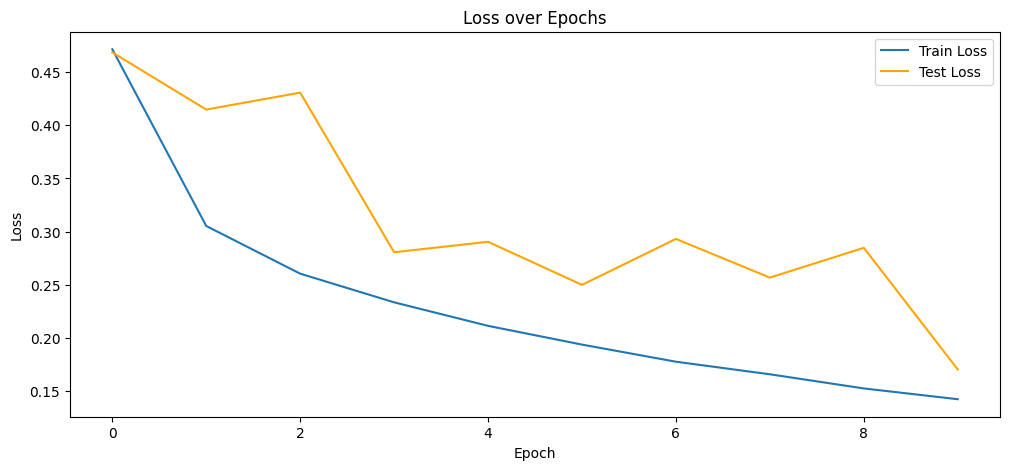

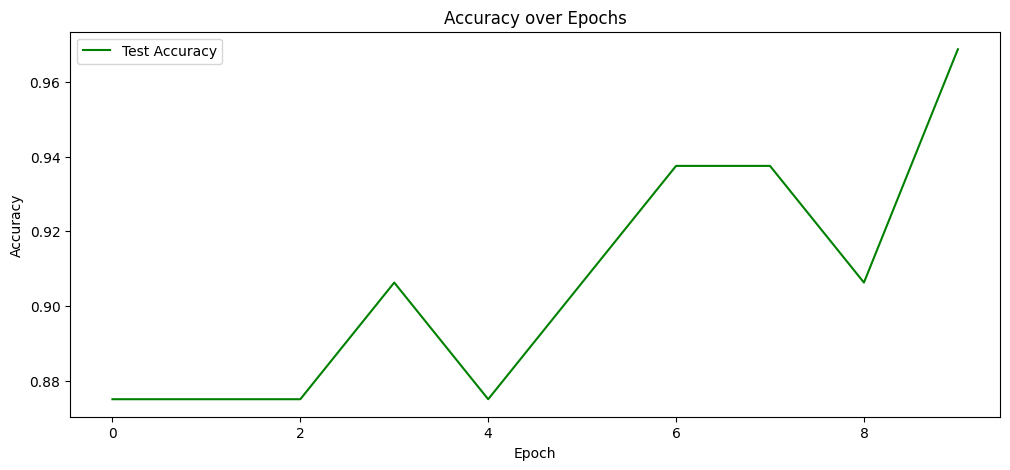

In [89]:
# Plot loss curves
plt.figure(figsize=(12, 5))
plt.plot(epoch_train_losses, label='Train Loss')
plt.plot(epoch_test_losses, label='Test Loss', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss over Epochs')
plt.show()

# Plot test accuracies
plt.figure(figsize=(12, 5))
plt.plot(epoch_test_accuracies, label='Test Accuracy', color='green')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy over Epochs')
plt.show()

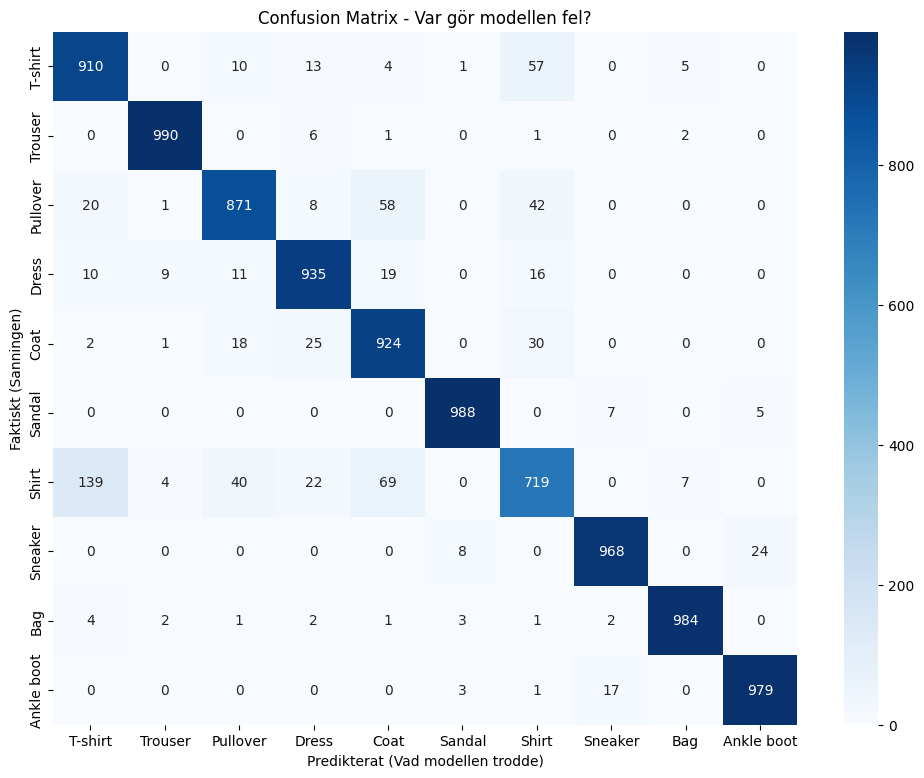

In [90]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import pandas as pd

def plot_confusion_matrix(model, dataloader, device):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            
            # Flytta till CPU för att numpy/sklearn ska kunna läsa datan
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            
    # Skapa matrisen
    cm = confusion_matrix(all_labels, all_preds)
    
    # FashionMNIST klassnamn
    classes = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat', 
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
    
    # Visualisera med Seaborn
    plt.figure(figsize=(12, 9))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=classes, yticklabels=classes)
    plt.xlabel('Predikterat (Vad modellen trodde)')
    plt.ylabel('Faktiskt (Sanningen)')
    plt.title('Confusion Matrix - Var gör modellen fel?')
    plt.show()

# Kör funktionen efter din träning
plot_confusion_matrix(model, test_dataloader, device)

In [85]:
classes = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat', 
           'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

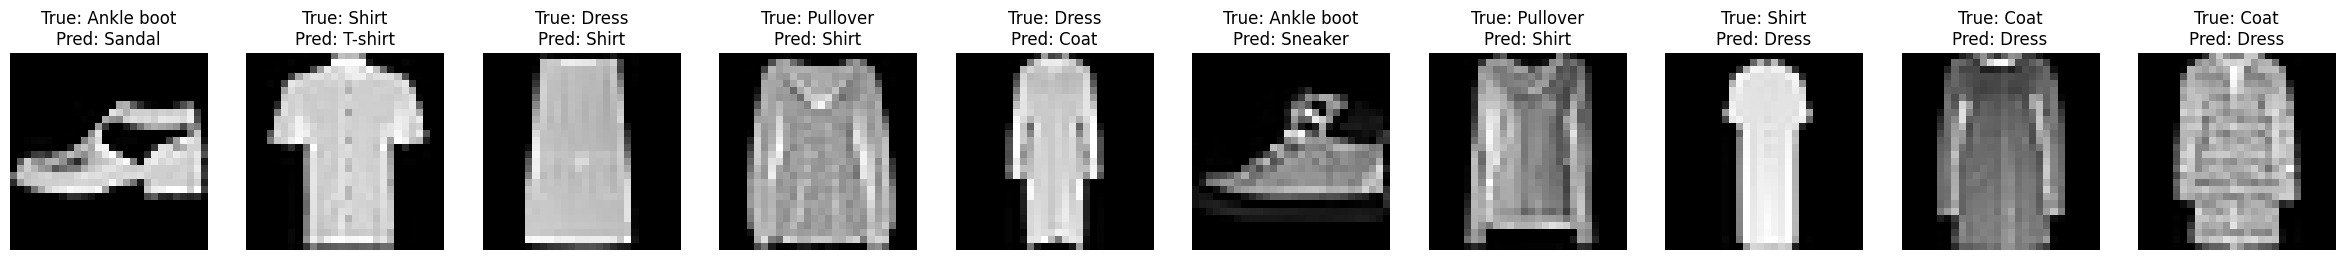

In [91]:
def show_errors(model, dataloader, device, num_images=10):
    model.eval()
    errors = []
    
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            
            # Hitta index där prediktionen var fel
            mask = preds != labels.to(device)
            if mask.any():
                err_imgs = images[mask]
                err_labels = labels.to(device)[mask]
                err_preds = preds[mask]
                
                for i in range(len(err_imgs)):
                    errors.append((err_imgs[i].cpu(), err_labels[i].cpu(), err_preds[i].cpu()))
            
            if len(errors) >= num_images: break

    # Plotta felen
    plt.figure(figsize=(30, 10))
    for i in range(num_images):
        img, true_label, pred_label = errors[i]
        plt.subplot(1, num_images, i+1)
        plt.imshow(img.squeeze(), cmap='gray')
        plt.title(f"True: {classes[true_label]}\nPred: {classes[pred_label]}")
        plt.axis('off')
    plt.show()

show_errors(model, test_dataloader, device)

In [92]:
from sklearn.metrics import classification_report

def detailed_error_analysis(model, dataloader, device):
    model.eval()
    all_preds = []
    all_labels = []
    
    # FashionMNIST klassnamn
    classes = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat', 
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
    
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
    
    # Skapa rapporten
    report = classification_report(all_labels, all_preds, target_names=classes)
    print("--- Detaljerad Error Analys Per Klass ---")
    print(report)

# Kör analysen
detailed_error_analysis(model, test_dataloader, device)

--- Detaljerad Error Analys Per Klass ---
              precision    recall  f1-score   support

     T-shirt       0.84      0.91      0.87      1000
     Trouser       0.98      0.99      0.99      1000
    Pullover       0.92      0.87      0.89      1000
       Dress       0.92      0.94      0.93      1000
        Coat       0.86      0.92      0.89      1000
      Sandal       0.99      0.99      0.99      1000
       Shirt       0.83      0.72      0.77      1000
     Sneaker       0.97      0.97      0.97      1000
         Bag       0.99      0.98      0.98      1000
  Ankle boot       0.97      0.98      0.98      1000

    accuracy                           0.93     10000
   macro avg       0.93      0.93      0.93     10000
weighted avg       0.93      0.93      0.93     10000

